---

# LESSON 20: ASSIGNMENT 3 - DUAL AXIS LINE CHARTS

---

>---
>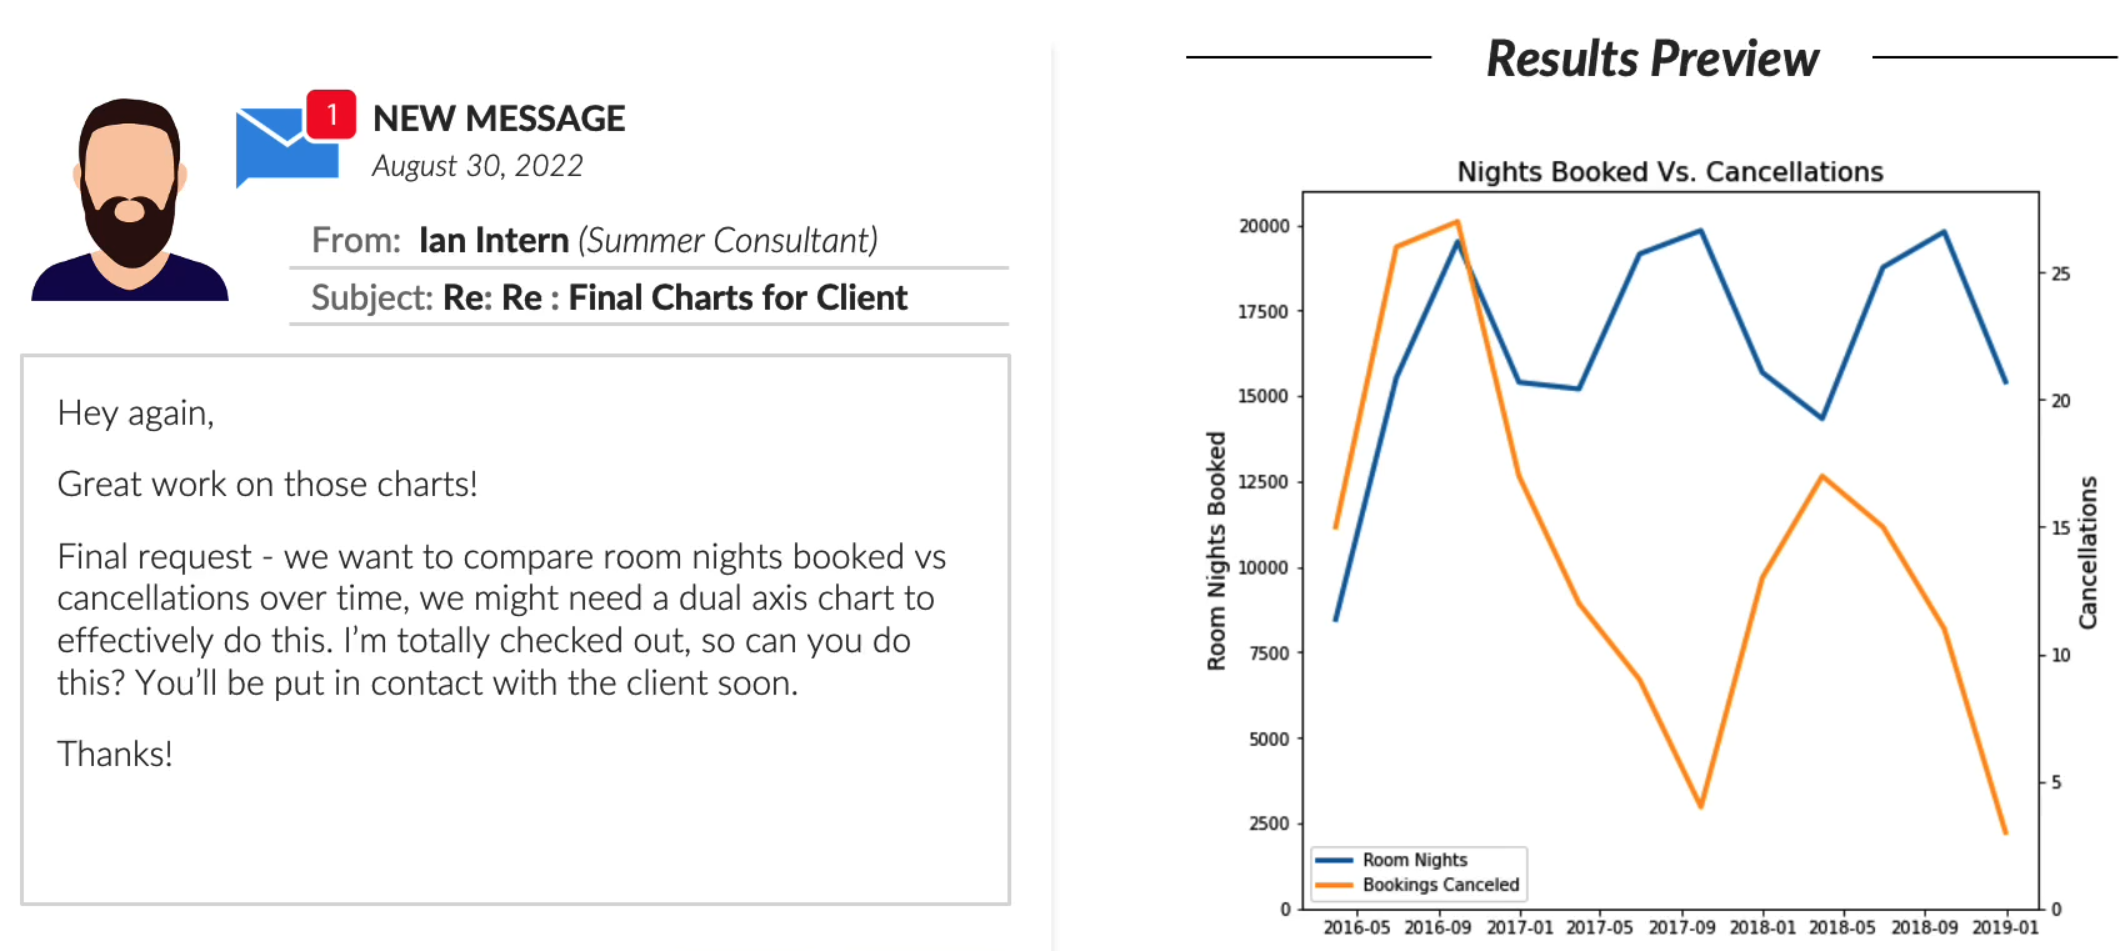
>
>---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('white')

In [2]:
df = pd.read_excel('../Data/HotelCustomersDataset.xlsx')

df = df[['DaysSinceCreation', 'RoomNights', 'BookingsCanceled']]

display(df.head(3), df.tail(3))
df.info()

,DaysSinceCreation,RoomNights,BookingsCanceled
0,150,5,1
1,1095,5,0
2,1095,0,0


,DaysSinceCreation,RoomNights,BookingsCanceled
83587,0,0,0
83588,0,3,0
83589,0,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83590 entries, 0 to 83589
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   DaysSinceCreation  83590 non-null  int64
 1   RoomNights         83590 non-null  int64
 2   BookingsCanceled   83590 non-null  int64
dtypes: int64(3)
memory usage: 1.9 MB


In [3]:
df['date'] = (pd
    .to_datetime('2018-12-31') - pd
        .to_timedelta(df.DaysSinceCreation, unit='D')).astype('datetime64[ns]')
df = df.reindex(columns=['date', 'RoomNights', 'BookingsCanceled']).set_index('date').sort_index()
df

,RoomNights,BookingsCanceled
date,,
2016-01-01,0,0
2016-01-01,3,0
2016-01-01,0,0
2016-01-01,4,0
2016-01-01,1,0
...,...,...
2018-12-31,0,0
2018-12-31,3,0
2018-12-31,0,0


In [4]:
df_plot = df.resample('QE').sum().round().copy()
df_plot

,RoomNights,BookingsCanceled
date,,
2016-03-31,8464,15
2016-06-30,15535,26
2016-09-30,19517,27
2016-12-31,15404,17
2017-03-31,15206,12
2017-06-30,19159,9
2017-09-30,19844,4
2017-12-31,15691,13
2018-03-31,14338,17


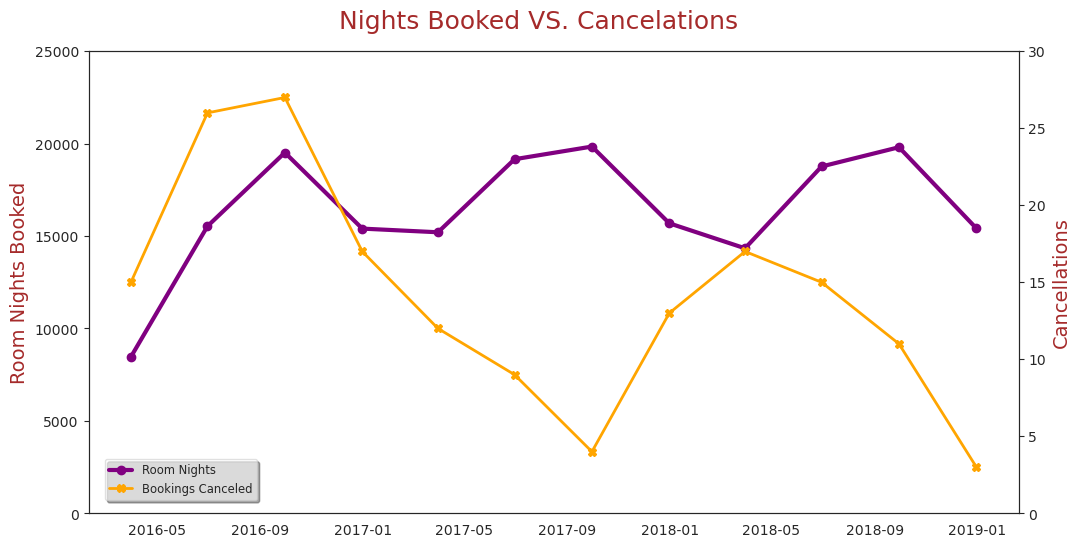

In [29]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)

ax.plot(df_plot.index, df_plot.RoomNights, label='Room Nights',
        color='purple', linewidth=3, marker='o')
ax.set_ylabel('Room Nights Booked', fontsize=14, color='brown')
ax.set_ylim(0, 25000)


ax2 = ax.twinx()
ax2.plot(df_plot.index, df_plot.BookingsCanceled, label='Bookings Canceled',
         color='orange', linewidth=2, marker='X')
ax2.set_ylabel('Cancellations', fontsize=14, color='brown')
ax2.set_ylim(0, 30)

fig.suptitle('Nights Booked VS. Cancelations', fontsize=18, color='brown', y=0.95)

fig.legend(bbox_to_anchor=(0.27, 0.21),
          shadow=True, framealpha=0.6,
          fontsize='small')
plt.show()